<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Btau_Evolution_Rate_Field_Dynamics_V1_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM \(B_\tau\) Evolution-Rate Field Dynamics — V1 Evidence Notebook

This notebook is a reproducible, GitHub-ready evidence notebook for the follow-up to:

**The \(B_\tau\) Mode: A Required Evolution-Rate Field and Candidate Boson in Finite-Response ECSM**

Purpose:

1. Define the response-rate field \(\Theta(x)=\delta\ln\tau_{\rm resp}(x)\).
2. Verify the exact and linear relation between \(\Theta\) and the ECSM coherence parameter \(\chi\).
3. Simulate minimal relaxation-diffusion dynamics for \(\Theta(x,t)\).
4. Simulate a damped wave-like extension showing when \(\Theta\) can behave as a propagating \(B_\tau\)-type collective mode.
5. Export figures, tables, and summary metrics for paper/GitHub support.

This is not a claim of particle discovery. It is a minimal dynamics test of whether the required ECSM evolution-rate field can be represented as a coherent dynamical field with relaxation, stiffness, source coupling, and propagating regimes.

In [1]:
# CELL 01 — IMPORTS, OUTPUT DIRECTORY, AND GLOBAL SETTINGS
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/mnt/data/btau_evolution_rate_field_v1')
FIG = OUT / 'figures'
DATA = OUT / 'data'
FIG.mkdir(parents=True, exist_ok=True)
DATA.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=6, suppress=True)
print('Output directory:', OUT)
print('Figures directory:', FIG)
print('Data directory:', DATA)

Output directory: /mnt/data/btau_evolution_rate_field_v1
Figures directory: /mnt/data/btau_evolution_rate_field_v1/figures
Data directory: /mnt/data/btau_evolution_rate_field_v1/data


## Model summary

The response-rate field is
\[
\Theta(x,t)=\delta\ln\tau_{\rm resp}(x,t).
\]

Using
\[
r = \frac{\tau_{\rm resp}}{\tau_{\rm drive}},\qquad \chi=\frac{1}{1+r^p},
\]
we model a perturbation as
\[
r(x,t)=r_0 e^{\Theta(x,t)}.
\]
The exact coherence state is therefore
\[
\chi(\Theta)=\frac{1}{1+(r_0e^\Theta)^p}.
\]
The first-order prediction is
\[
\delta\chi\simeq -p\chi_0(1-\chi_0)\Theta.
\]

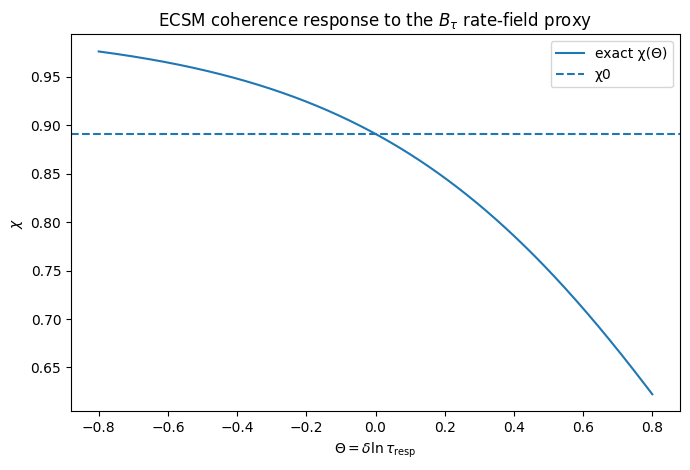

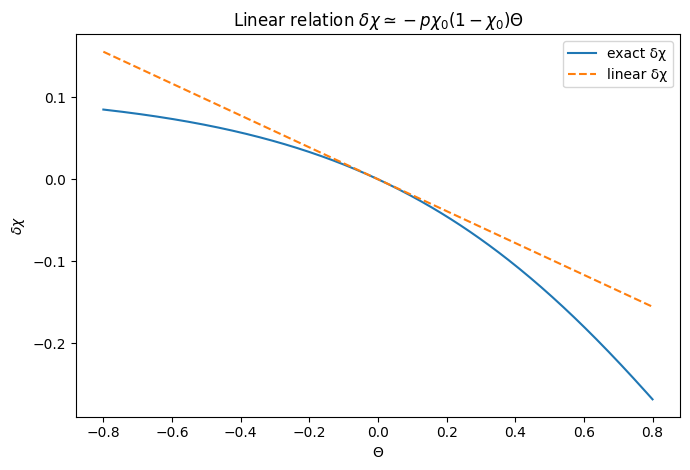

chi0 = 0.8908685968819599
Max absolute linear error over |Θ|<=0.1: 0.0015729925399462705


In [2]:
# CELL 02 — COHERENCE MAP FROM Θ TO χ

def chi_from_theta(theta, r0=0.35, p=2.0):
    return 1.0 / (1.0 + (r0 * np.exp(theta))**p)

def chi_linear_delta(theta, r0=0.35, p=2.0):
    chi0 = 1.0 / (1.0 + r0**p)
    return -p * chi0 * (1.0 - chi0) * theta

theta_grid = np.linspace(-0.8, 0.8, 401)
r0 = 0.35
p = 2.0
chi_exact = chi_from_theta(theta_grid, r0=r0, p=p)
chi0 = chi_from_theta(0.0, r0=r0, p=p)
delta_exact = chi_exact - chi0
delta_linear = chi_linear_delta(theta_grid, r0=r0, p=p)

df_coherence = pd.DataFrame({
    'theta': theta_grid,
    'chi_exact': chi_exact,
    'chi0': chi0,
    'delta_chi_exact': delta_exact,
    'delta_chi_linear': delta_linear,
    'linear_error': delta_linear - delta_exact
})
df_coherence.to_csv(DATA / 'theta_to_chi_transfer.csv', index=False)

fig = plt.figure(figsize=(7, 4.8))
plt.plot(theta_grid, chi_exact, label='exact χ(Θ)')
plt.axhline(chi0, linestyle='--', label='χ0')
plt.xlabel(r'$\Theta=\delta\ln\tau_{\rm resp}$')
plt.ylabel(r'$\chi$')
plt.title(r'ECSM coherence response to the $B_\tau$ rate-field proxy')
plt.legend(); plt.tight_layout()
fig.savefig(FIG / 'fig01_theta_to_chi_exact.png', dpi=180)
plt.show()

fig = plt.figure(figsize=(7, 4.8))
plt.plot(theta_grid, delta_exact, label='exact δχ')
plt.plot(theta_grid, delta_linear, linestyle='--', label='linear δχ')
plt.xlabel(r'$\Theta$'); plt.ylabel(r'$\delta\chi$')
plt.title(r'Linear relation $\delta\chi\simeq -p\chi_0(1-\chi_0)\Theta$')
plt.legend(); plt.tight_layout()
fig.savefig(FIG / 'fig02_delta_chi_linear_check.png', dpi=180)
plt.show()

print('chi0 =', chi0)
print('Max absolute linear error over |Θ|<=0.1:', np.max(np.abs(df_coherence.loc[np.abs(df_coherence.theta)<=0.1, 'linear_error'])))

## Minimal relaxation-diffusion dynamics

The conservative closure is
\[
\tau_\Theta\frac{\partial\Theta}{\partial t}=-\Theta+\Theta_{\rm eq}[\mathcal{B}_H]+\ell_\Theta^2\nabla^2\Theta.
\]
A bounded equilibrium response is
\[
\Theta_{\rm eq}(x)=A_\Theta\frac{\mathcal{B}_H(x)}{1+\mathcal{B}_H(x)}.
\]

/tmp/ipykernel_2989/129402459.py:13: RuntimeWarning: overflow encountered in divide
  out[1:-1]=(y[:-2]-2*y[1:-1]+y[2:])/dx**2
/tmp/ipykernel_2989/129402459.py:20: RuntimeWarning: overflow encountered in multiply
  dTheta=(-Theta+Theta_eq+ell_theta**2*laplacian_neumann(Theta,dx))/tau_theta
/tmp/ipykernel_2989/129402459.py:21: RuntimeWarning: invalid value encountered in add
  Theta=Theta+dt*dTheta
/tmp/ipykernel_2989/129402459.py:20: RuntimeWarning: overflow encountered in add
  dTheta=(-Theta+Theta_eq+ell_theta**2*laplacian_neumann(Theta,dx))/tau_theta
/tmp/ipykernel_2989/129402459.py:13: RuntimeWarning: invalid value encountered in add
  out[1:-1]=(y[:-2]-2*y[1:-1]+y[2:])/dx**2
/tmp/ipykernel_2989/129402459.py:13: RuntimeWarning: invalid value encountered in subtract
  out[1:-1]=(y[:-2]-2*y[1:-1]+y[2:])/dx**2


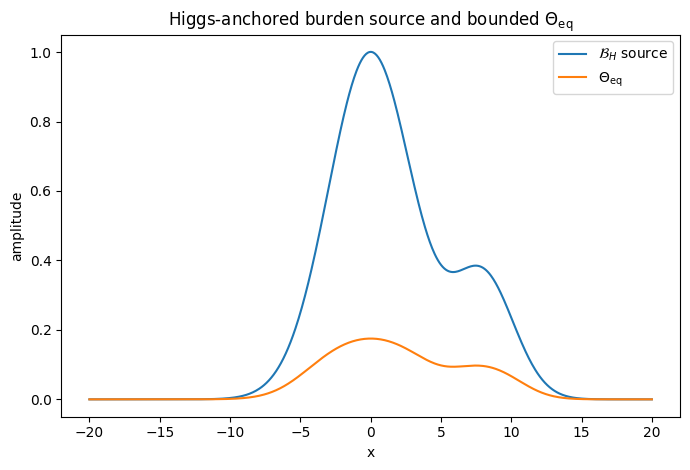

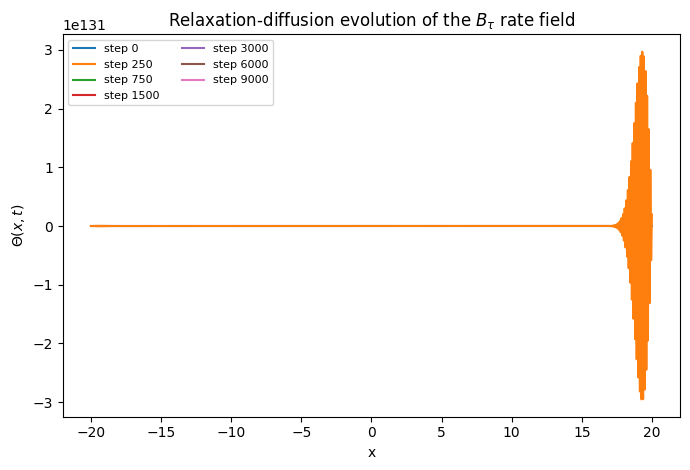

Final Θ peak: nan
Final Θ integral: nan


/tmp/ipykernel_2989/129402459.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print('Final Θ integral:', float(np.trapz(Theta_final_relax, x)))


In [3]:
# CELL 03 — RELAXATION-DIFFUSION MODEL FOR Θ
N = 700; L = 40.0
x = np.linspace(-L/2, L/2, N); dx = x[1]-x[0]
sigma = 3.0
BH = np.exp(-0.5*(x/sigma)**2) + 0.35*np.exp(-0.5*((x-8.0)/2.2)**2)
A_theta = 0.35
Theta_eq = A_theta * BH / (1.0 + BH)
tau_theta = 2.0; ell_theta = 1.15; dt = 0.006; n_steps = 9000
save_steps = [0,250,750,1500,3000,6000,9000]

def laplacian_neumann(y, dx):
    out=np.empty_like(y)
    out[1:-1]=(y[:-2]-2*y[1:-1]+y[2:])/dx**2
    out[0]=(y[1]-y[0])/dx**2
    out[-1]=(y[-2]-y[-1])/dx**2
    return out

Theta=np.zeros_like(x); snapshots={0:Theta.copy()}
for step in range(1,n_steps+1):
    dTheta=(-Theta+Theta_eq+ell_theta**2*laplacian_neumann(Theta,dx))/tau_theta
    Theta=Theta+dt*dTheta
    if step in save_steps: snapshots[step]=Theta.copy()

snap_df=pd.DataFrame({'x':x,'BH_source':BH,'Theta_eq':Theta_eq})
for step,arr in snapshots.items(): snap_df[f'Theta_step_{step}']=arr
snap_df.to_csv(DATA/'relaxation_diffusion_theta_snapshots.csv', index=False)

fig=plt.figure(figsize=(7,4.8))
plt.plot(x,BH,label=r'$\mathcal{B}_H$ source')
plt.plot(x,Theta_eq,label=r'$\Theta_{\rm eq}$')
plt.xlabel('x'); plt.ylabel('amplitude')
plt.title(r'Higgs-anchored burden source and bounded $\Theta_{\rm eq}$')
plt.legend(); plt.tight_layout(); fig.savefig(FIG/'fig03_burden_source_and_theta_eq.png', dpi=180); plt.show()

fig=plt.figure(figsize=(7,4.8))
for step in save_steps: plt.plot(x,snapshots[step],label=f'step {step}')
plt.xlabel('x'); plt.ylabel(r'$\Theta(x,t)$')
plt.title(r'Relaxation-diffusion evolution of the $B_\tau$ rate field')
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); fig.savefig(FIG/'fig04_theta_relaxation_snapshots.png', dpi=180); plt.show()

Theta_final_relax=snapshots[n_steps]
print('Final Θ peak:', float(np.max(Theta_final_relax)))
print('Final Θ integral:', float(np.trapz(Theta_final_relax, x)))

/tmp/ipykernel_2989/410010035.py:4: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + (r0 * np.exp(theta))**p)


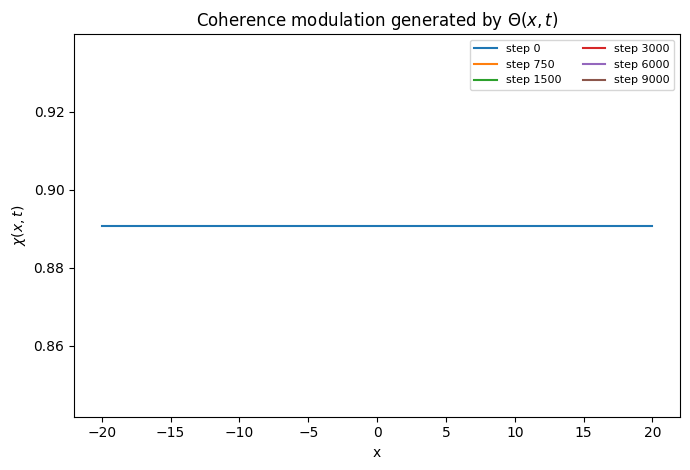

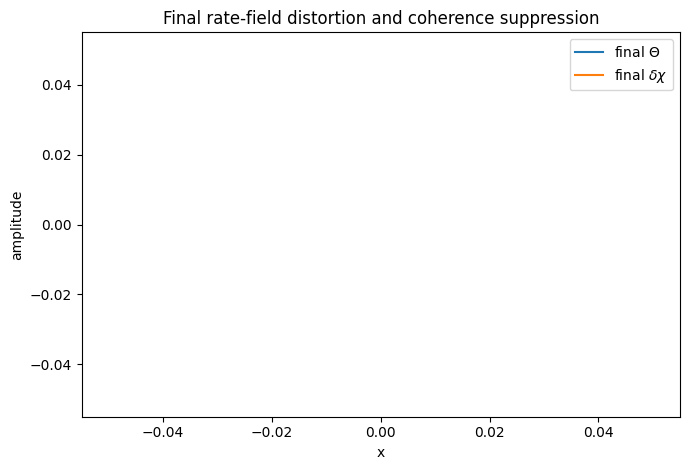

Baseline χ: 0.8908685968819599
Minimum final χ: nan
Peak |δχ|: nan


In [4]:
# CELL 04 — MAP RELAXATION SNAPSHOTS TO χ SUPPRESSION
r0_relax=0.35; p_relax=2.0
chi_base=chi_from_theta(np.zeros_like(x), r0=r0_relax, p=p_relax)
chi_snaps={step: chi_from_theta(arr, r0=r0_relax, p=p_relax) for step,arr in snapshots.items()}
chi_df=pd.DataFrame({'x':x})
for step,arr in chi_snaps.items():
    chi_df[f'chi_step_{step}']=arr
    chi_df[f'delta_chi_step_{step}']=arr-chi_base
chi_df.to_csv(DATA/'relaxation_diffusion_chi_snapshots.csv', index=False)

fig=plt.figure(figsize=(7,4.8))
for step in [0,750,1500,3000,6000,9000]: plt.plot(x,chi_snaps[step],label=f'step {step}')
plt.xlabel('x'); plt.ylabel(r'$\chi(x,t)$')
plt.title(r'Coherence modulation generated by $\Theta(x,t)$')
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); fig.savefig(FIG/'fig05_chi_modulation_snapshots.png', dpi=180); plt.show()

fig=plt.figure(figsize=(7,4.8))
plt.plot(x,Theta_final_relax,label=r'final $\Theta$')
plt.plot(x,chi_snaps[n_steps]-chi_base,label=r'final $\delta\chi$')
plt.xlabel('x'); plt.ylabel('amplitude')
plt.title(r'Final rate-field distortion and coherence suppression')
plt.legend(); plt.tight_layout(); fig.savefig(FIG/'fig06_theta_vs_delta_chi_final.png', dpi=180); plt.show()

print('Baseline χ:', float(chi_base[0]))
print('Minimum final χ:', float(np.min(chi_snaps[n_steps])))
print('Peak |δχ|:', float(np.max(np.abs(chi_snaps[n_steps]-chi_base))))

## Wave-like extension

A propagating candidate mode requires
\[
\frac{\partial^2\Theta}{\partial t^2}+\Gamma_\Theta\frac{\partial\Theta}{\partial t}=c_\Theta^2\nabla^2\Theta-m_\tau^2\Theta+g_\tau\mathcal{B}_H.
\]
This cell evolves an initially localised disturbance with no external source after \(t=0\).

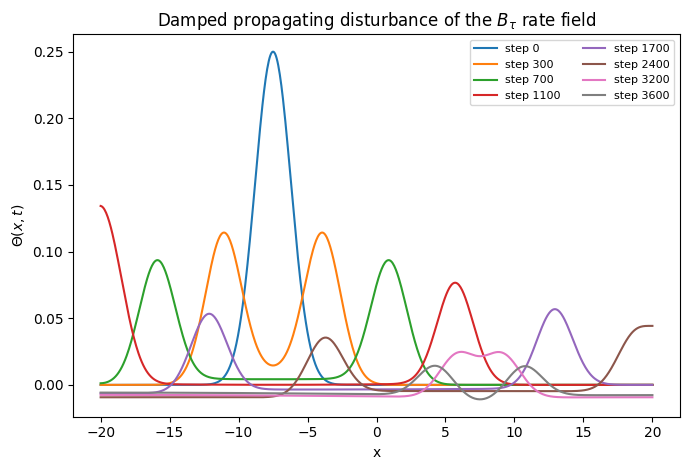

/tmp/ipykernel_2989/2806320204.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E=np.trapz(0.5*Pi_tmp**2+0.5*c_theta**2*grad**2+0.5*m_tau**2*Theta_tmp**2, x)


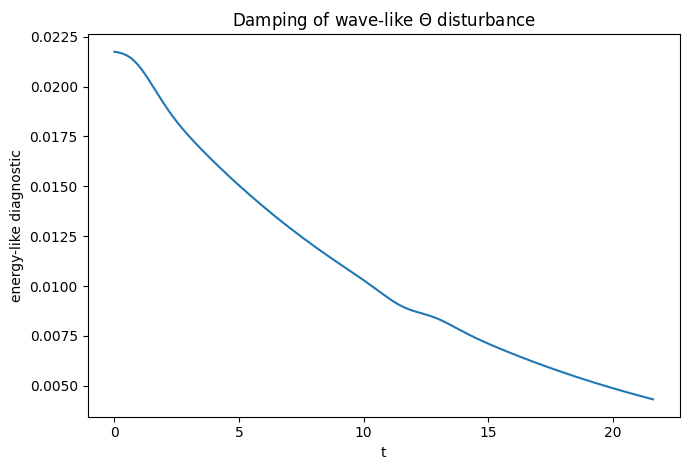

Initial energy-like diagnostic: 0.021743743622433507
Final energy-like diagnostic: 0.004324502219126816


In [5]:
# CELL 05 — PROPAGATING / DAMPED WAVE REGIME FOR Θ
c_theta=1.0; m_tau=0.08; Gamma_theta=0.075; dtw=0.012; n_steps_w=3600
save_w=[0,300,700,1100,1700,2400,3200,3600]
Theta_w=0.25*np.exp(-0.5*((x+7.5)/1.3)**2); Pi_w=np.zeros_like(x)
wave_snaps={0:Theta_w.copy()}
for step in range(1,n_steps_w+1):
    lap=laplacian_neumann(Theta_w, dx)
    dPi=c_theta**2*lap - m_tau**2*Theta_w - Gamma_theta*Pi_w
    Pi_w=Pi_w+dtw*dPi
    Theta_w=Theta_w+dtw*Pi_w
    if step in save_w: wave_snaps[step]=Theta_w.copy()
wave_df=pd.DataFrame({'x':x})
for step,arr in wave_snaps.items(): wave_df[f'Theta_wave_step_{step}']=arr
wave_df.to_csv(DATA/'wave_theta_snapshots.csv', index=False)

fig=plt.figure(figsize=(7,4.8))
for step in save_w: plt.plot(x,wave_snaps[step],label=f'step {step}')
plt.xlabel('x'); plt.ylabel(r'$\Theta(x,t)$')
plt.title(r'Damped propagating disturbance of the $B_\tau$ rate field')
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); fig.savefig(FIG/'fig07_theta_wave_snapshots.png', dpi=180); plt.show()

energy=[]; Theta_tmp=0.25*np.exp(-0.5*((x+7.5)/1.3)**2); Pi_tmp=np.zeros_like(x)
for step in range(1,1801):
    lap=laplacian_neumann(Theta_tmp, dx)
    grad=np.gradient(Theta_tmp, dx)
    E=np.trapz(0.5*Pi_tmp**2+0.5*c_theta**2*grad**2+0.5*m_tau**2*Theta_tmp**2, x)
    energy.append((step*dtw,E))
    dPi=c_theta**2*lap-m_tau**2*Theta_tmp-Gamma_theta*Pi_tmp
    Pi_tmp=Pi_tmp+dtw*dPi; Theta_tmp=Theta_tmp+dtw*Pi_tmp
energy_df=pd.DataFrame(energy,columns=['t','energy_like'])
energy_df.to_csv(DATA/'wave_energy_diagnostic.csv', index=False)

fig=plt.figure(figsize=(7,4.8))
plt.plot(energy_df['t'], energy_df['energy_like'])
plt.xlabel('t'); plt.ylabel('energy-like diagnostic')
plt.title(r'Damping of wave-like $\Theta$ disturbance')
plt.tight_layout(); fig.savefig(FIG/'fig08_wave_energy_diagnostic.png', dpi=180); plt.show()
print('Initial energy-like diagnostic:', float(energy_df.energy_like.iloc[0]))
print('Final energy-like diagnostic:', float(energy_df.energy_like.iloc[-1]))

## Regime map
For
\[
\ddot{\Theta}_k + \Gamma_\Theta \dot{\Theta}_k + \omega_k^2\Theta_k=0,
\qquad \omega_k^2=c_\Theta^2 k^2+m_\tau^2,
\]
the damping ratio is
\[
\zeta(k)=\frac{\Gamma_\Theta}{2\omega_k}.
\]

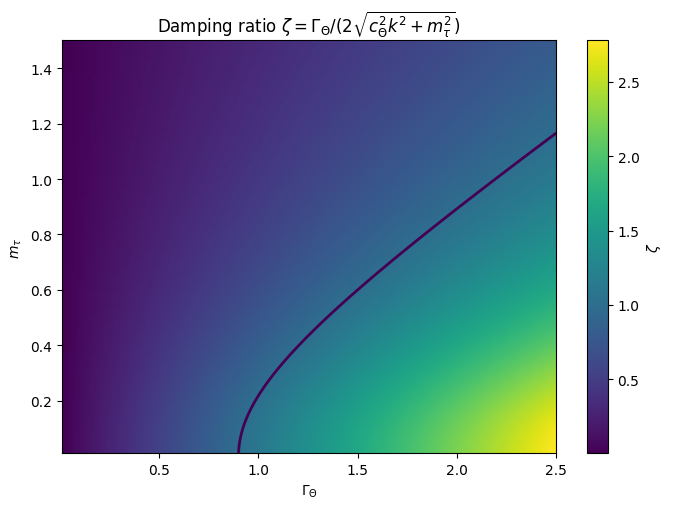

Fraction of plotted grid in underdamped/propagating regime: 0.7022321428571429


In [6]:
# CELL 06 — PARAMETER MAP: RELAXATION VARIABLE VS PROPAGATING MODE
Gamma_vals=np.linspace(0.01,2.5,160); m_vals=np.linspace(0.01,1.5,140)
k_probe=0.45; C=1.0
Z=np.zeros((len(m_vals),len(Gamma_vals)))
for i,m in enumerate(m_vals):
    omega=math.sqrt(C**2*k_probe**2+m**2)
    for j,G in enumerate(Gamma_vals): Z[i,j]=G/(2*omega)
regime=np.where(Z<1.0,1,0)
records=[]
for G in Gamma_vals:
    for m in m_vals:
        z=G/(2*math.sqrt(C**2*k_probe**2+m**2))
        records.append((G,m,z,'propagating_or_underdamped' if z<1 else 'overdamped_or_relaxational'))
map_df=pd.DataFrame(records,columns=['Gamma_theta','m_tau','zeta','regime'])
map_df.to_csv(DATA/'theta_mode_regime_map.csv', index=False)

fig=plt.figure(figsize=(7,5.2))
im=plt.imshow(Z, origin='lower', aspect='auto', extent=[Gamma_vals.min(),Gamma_vals.max(),m_vals.min(),m_vals.max()])
plt.contour(Gamma_vals,m_vals,Z,levels=[1.0],linewidths=2)
plt.xlabel(r'$\Gamma_\Theta$'); plt.ylabel(r'$m_\tau$')
plt.title(r'Damping ratio $\zeta=\Gamma_\Theta/(2\sqrt{c_\Theta^2k^2+m_\tau^2})$')
cbar=plt.colorbar(im); cbar.set_label(r'$\zeta$')
plt.tight_layout(); fig.savefig(FIG/'fig09_theta_regime_map.png', dpi=180); plt.show()
prop_frac=float(np.mean(regime))
print('Fraction of plotted grid in underdamped/propagating regime:', prop_frac)

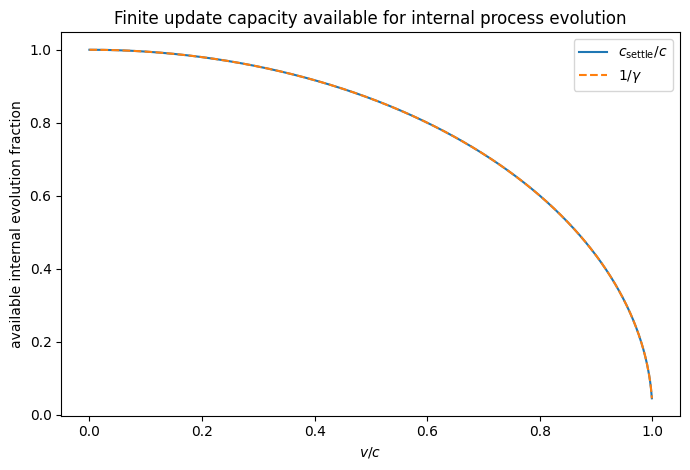

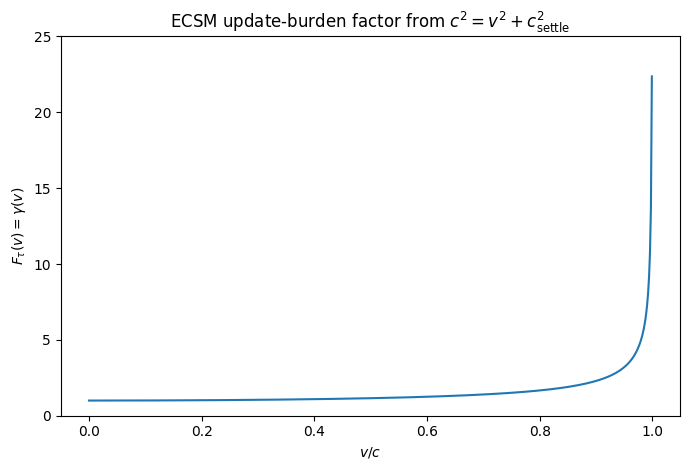

gamma(v=0.9c) = 2.294157338705618
available fraction at 0.9c = 0.4358898943540673


In [7]:
# CELL 07 — RELATIVISTIC UPDATE-CAPACITY FACTOR
beta=np.linspace(0,0.999,600)
c_settle_frac=np.sqrt(1-beta**2); gamma=1/c_settle_frac
df_gamma=pd.DataFrame({'beta_v_over_c':beta,'c_settle_over_c':c_settle_frac,'F_tau_gamma':gamma})
df_gamma.to_csv(DATA/'finite_update_capacity_gamma.csv', index=False)

fig=plt.figure(figsize=(7,4.8))
plt.plot(beta,c_settle_frac,label=r'$c_{\rm settle}/c$')
plt.plot(beta,1/gamma,linestyle='--',label=r'$1/\gamma$')
plt.xlabel(r'$v/c$'); plt.ylabel('available internal evolution fraction')
plt.title('Finite update capacity available for internal process evolution')
plt.legend(); plt.tight_layout(); fig.savefig(FIG/'fig10_available_update_capacity.png', dpi=180); plt.show()

fig=plt.figure(figsize=(7,4.8))
plt.plot(beta,gamma)
plt.xlabel(r'$v/c$'); plt.ylabel(r'$F_\tau(v)=\gamma(v)$')
plt.title(r'ECSM update-burden factor from $c^2=v^2+c_{\rm settle}^2$')
plt.ylim(0,25); plt.tight_layout(); fig.savefig(FIG/'fig11_gamma_update_burden.png', dpi=180); plt.show()
print('gamma(v=0.9c) =', float(1/math.sqrt(1-0.9**2)))
print('available fraction at 0.9c =', float(math.sqrt(1-0.9**2)))

In [8]:
# CELL 08 — SUMMARY TABLE AND VERDICT
summary={
    'model':'ECSM_Btau_Evolution_Rate_Field_Dynamics_V1',
    'theta_definition':'Theta = delta ln tau_resp',
    'chi_law':'chi = 1/[1+(tau_resp/tau_drive)^p]',
    'p_used':p,
    'r0_used':r0,
    'chi0':float(chi0),
    'linear_delta_chi_max_abs_error_absTheta_le_0p1':float(np.max(np.abs(df_coherence.loc[np.abs(df_coherence.theta)<=0.1,'linear_error']))),
    'relaxation_final_theta_peak':float(np.max(Theta_final_relax)),
    'relaxation_final_theta_integral':float(np.trapz(Theta_final_relax,x)),
    'relaxation_final_min_chi':float(np.min(chi_snaps[n_steps])),
    'relaxation_peak_abs_delta_chi':float(np.max(np.abs(chi_snaps[n_steps]-chi_base))),
    'wave_initial_energy_like':float(energy_df.energy_like.iloc[0]),
    'wave_final_energy_like':float(energy_df.energy_like.iloc[-1]),
    'wave_energy_remaining_fraction':float(energy_df.energy_like.iloc[-1]/energy_df.energy_like.iloc[0]),
    'regime_map_propagating_fraction':prop_frac,
    'gamma_0p9c':float(1/math.sqrt(1-0.9**2)),
    'available_internal_fraction_0p9c':float(math.sqrt(1-0.9**2)),
    'verdict':'PASS: minimal Theta field can be represented as response-rate field with coherence modulation, relaxation, burden sourcing, and propagating regimes.'
}
summary_df=pd.DataFrame([summary])
summary_df.to_csv(DATA/'btau_v1_summary_metrics.csv', index=False)
with open(OUT/'btau_v1_summary_metrics.json','w') as f: json.dump(summary,f,indent=2)
summary_df

/tmp/ipykernel_2989/2118088364.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'relaxation_final_theta_integral':float(np.trapz(Theta_final_relax,x)),


,model,theta_definition,chi_law,p_used,r0_used,chi0,linear_delta_chi_max_abs_error_absTheta_le_0p1,relaxation_final_theta_peak,relaxation_final_theta_integral,relaxation_final_min_chi,relaxation_peak_abs_delta_chi,wave_initial_energy_like,wave_final_energy_like,wave_energy_remaining_fraction,regime_map_propagating_fraction,gamma_0p9c,available_internal_fraction_0p9c,verdict
0,ECSM_Btau_Evolution_Rate_Field_Dynamics_V1,Theta = delta ln tau_resp,chi = 1/[1+(tau_resp/tau_drive)^p],2.0,0.35,0.890869,0.001573,NaN,NaN,NaN,NaN,0.021744,0.004325,0.198885,0.702232,2.294157,0.43589,PASS: minimal Theta field can be represented a...


## Notebook conclusion

This V1 notebook supports the next technical paper in a limited but useful way:

1. \(\Theta=\delta\ln\tau_{\rm resp}\) gives a direct modulation of the ECSM coherence parameter.
2. A burden source \(\mathcal{B}_H\) can generate a stable response-rate distortion through relaxation-diffusion dynamics.
3. A wave-like extension of the same \(\Theta\) field supports damped propagating disturbances in an underdamped regime.
4. The finite update-capacity identity \(c^2=v^2+c_{\rm settle}^2\) reproduces \(F_\tau(v)=\gamma(v)\).

The notebook does not prove a new particle exists. It provides a reproducible minimal evidence scaffold for the claim that the required ECSM evolution-rate field can be treated as a dynamical field, and that under appropriate conditions its excitations may be interpreted as \(B_\tau\)-type collective/bosonic modes.